# 00 — NumPy and Image Fundamentals

Before training a classifier, we need to be comfortable treating images as numerical arrays. This notebook focuses on shapes, indexing, broadcasting, and vectorization—the tools used throughout CS231n.

## Learning objectives

By the end, you should be able to:

- explain how a color image is stored as an array;
- distinguish one image from a batch of images by shape;
- use indexing and broadcasting without losing track of dimensions;
- replace a Python loop with a vectorized NumPy operation;
- check that two implementations produce the same result.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=2, suppress=True)

Matplotlib is building the font cache; this may take a moment.


## 1. An image is an array

We will use the **HWC** convention: `(height, width, channels)`. An RGB image has three channels in the order red, green, blue. Pixel values below are floating-point numbers in `[0, 1]`.

shape: (8, 8, 3)
dtype: float32
range: 0.0 1.0


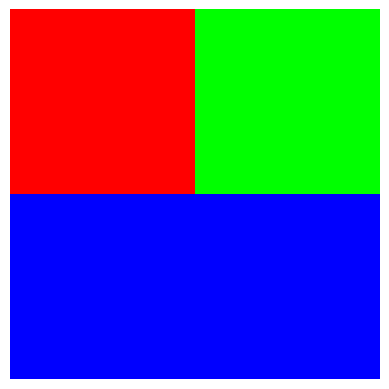

In [32]:
height, width, channels = 8, 8, 3
image = np.zeros((height, width, channels), dtype=np.float32)
image[:4, :4, 0] = 1.0  # red, top-left
image[:4, 4:, 1] = 1.0  # green, top-right
image[4:, :, 2] = 1.0   # blue, bottom

print("shape:", image.shape)
print("dtype:", image.dtype)
print("range:", image.min(), image.max())
plt.imshow(image)
plt.axis("off");

range: 0.0 1.0


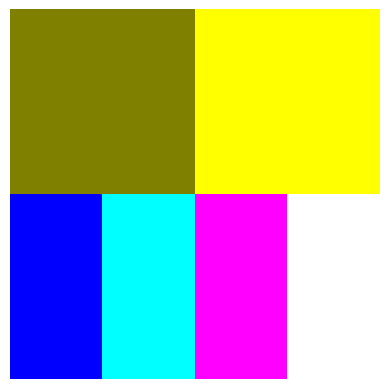

In [ ]:
# combining colorsexperiment
image_comb = np.zeros((height, width, channels), dtype=np.float32)
image_comb[:4, :4, 0] = 0.5  # semi-red, top-left
image_comb[:4, :4, 1] = 0.5  # semi-green, top-left
image_comb[:4, 4:, 0] = 1.0  # red, top-right
image_comb[:4, 4:, 1] = 1.0  # green, top-right
image_comb[4:, :, 2] = 1.0   # blue, bottom
image_comb[4:, 2:4, 1] = 1.0   # blue+green, bottom-center-left
image_comb[4:, 4:8, 0] = 1.0   # blue+red, bottom-center-right
image_comb[4:, 6:8, 1] = 1.0   # blue+red+green, bottom-right

print("range:", image_comb.min(), image_comb.max())
plt.imshow(image_comb)
plt.axis("off");

### Exercise 1 — Read an image array

Questions to answer in a Markdown cell below:

1. What does `image[0, 0]` represent?
2. Why does it have shape `(3,)` rather than `(1, 1, 3)`?
3. What information is selected by `image[:, :, 2]`?

1. `image[0, 0]` represent one pixel - 0, 0 top left
2. it have shape `(3,)` rather than `(1, 1, 3)` cause it is 1d array of 3 values (rgb)
3. by `image[:, :, 2]` we select all blue values

In [14]:
image[0, 0]

array([1., 0., 0.], dtype=float32)

In [11]:
image[0, 0].shape, image[:, :, 2].shape

((3,), (8, 8))

In [12]:
image[:, :, 2]

array([[0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1.]], dtype=float32)

In [7]:
top_left_pixel = image[0, 0]
blue_channel_shape = (8,8)
bottom_left_color = image[-1, 0]

np.testing.assert_array_equal(top_left_pixel, image[0, 0])
assert blue_channel_shape == image[:, :, 2].shape
np.testing.assert_array_equal(bottom_left_color, image[-1, 0])
print("Exercise 1 passed")

Exercise 1 passed


## 2. A batch adds one dimension

A batch of images commonly uses **NHWC** in NumPy: `(number, height, width, channels)`. Later, PyTorch convolutional layers will usually expect **NCHW** instead. Always inspect and document shapes.

In [15]:
batch = rng.random((5, height, width, channels), dtype=np.float32)
print("batch shape:", batch.shape)
print("one image shape:", batch[0].shape)
print("one pixel from every image shape:", batch[:, 0, 0, :].shape)

batch shape: (5, 8, 8, 3)
one image shape: (8, 8, 3)
one pixel from every image shape: (5, 3)


## 3. Broadcasting

Subtracting a channel mean with shape `(3,)` from a batch with shape `(N, H, W, 3)` works because NumPy compares dimensions from right to left. The three channel values are reused across every image and spatial location.

In [16]:
channel_mean = batch.mean(axis=(0, 1, 2))
centered = batch - channel_mean

print("batch shape:", batch.shape)
print("channel mean shape:", channel_mean.shape)
print("centered channel means:", centered.mean(axis=(0, 1, 2)))

batch shape: (5, 8, 8, 3)
channel mean shape: (3,)
centered channel means: [ 0.  0. -0.]


### Exercise 2 — Per-image means

Compute one mean RGB vector for each image. Your result must have shape `(5, 3)`. Do not use a Python loop. Think carefully about which axes represent spatial position.

In [24]:
# axis 1 - height, axis 2 - width
per_image_channel_mean = batch.mean(axis=(1, 2))

assert per_image_channel_mean.shape == (5, 3)
np.testing.assert_allclose(per_image_channel_mean[0], batch[0].mean(axis=(0, 1)))
print("Exercise 2 passed")

Exercise 2 passed


In [25]:
per_image_channel_mean

array([[0.5 , 0.54, 0.49],
       [0.51, 0.47, 0.49],
       [0.5 , 0.53, 0.44],
       [0.57, 0.52, 0.53],
       [0.46, 0.48, 0.52]], dtype=float32)

## 4. From loops to vectorization

A nearest-neighbor classifier compares an input with stored training examples. Here we compute squared Euclidean distances between one query image and every image in the batch. Flattening changes only the representation, not the underlying values.

In [26]:
query = rng.random((height, width, channels), dtype=np.float32)

loop_distances = np.empty(len(batch), dtype=np.float32)
for index, training_image in enumerate(batch):
    difference = training_image - query
    loop_distances[index] = np.sum(difference**2)

print(loop_distances)

[30.95 30.26 32.91 32.14 33.23]


### Exercise 3 — Vectorized distances

Reproduce `loop_distances` without a Python loop. Work out the shapes after subtraction and decide which axes must be summed. Do not use `np.linalg.norm` yet—the explicit operations make the shape reasoning visible.

In [29]:
(batch - query).shape

(5, 8, 8, 3)

In [ ]:
# Vectorized implementation of the above loop
# `batch - query` works cause numpy compares dimensions from the right, so it will broadcast query to the shape of batch
vectorized_distances = batch - query
vectorized_distances = np.sum(vectorized_distances**2, axis=(1, 2, 3))

assert vectorized_distances.shape == (len(batch),)
np.testing.assert_allclose(vectorized_distances, loop_distances, rtol=1e-6)
print("Exercise 3 passed")

Exercise 3 passed


## Reflection

Add a Markdown cell and answer briefly:

1. What does each axis of an `(N, H, W, C)` array mean?
2. Why can an array with shape `(H, W, C)` be subtracted from `(N, H, W, C)`?
3. In Exercise 3, which axes disappear after summation, and why?
4. Why should we compare the loop and vectorized results before trusting the faster version?

Next, we will generalize the distance computation to compare many query images with many training images and build a k-nearest-neighbor classifier.

1. N - number of items in batch, H - image height, W - image width, C - channels (usually 3 (rgb) for color images)
2. cause numpy compares dimensions from right to left
3. height, width and channels. we computed distance between batch images and test image
4. to make sure implementation is correct. With loop it is more straightforward and easier to implement